# Preliminary Exploration of a part of the yt8m-text dataset
In this notebook, we explore the yt8m-text data to gain a better understanding of what the obtained data consists of.

In [16]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from collections import Counter
import json

In [ ]:
df = pd.read_csv("../data/Youtube/yt8m_merged.csv")


In [3]:
print(df.head())

  yt8m_id   YouTube_id      label_ids_json  \
0    lHbu  RvYbu49cxgI              [0, 1]   
1    Nkbu  RvyIHsaWGqA                [92]   
2    Jmbu  ---swzKwadc  [21, 23, 24, 2058]   
3    TIbu  -1Rakk0j_Mw      [66, 332, 521]   
4    Izbu  -2E53z2QDbc              [2012]   

                                    label_names_json  num_labels  \
0                               ["Games", "Vehicle"]           2   
1                         ["Radio-controlled model"]           1   
2  ["Stadium", "Mobile phone", "String instrument...           4   
3            ["Bollywood", "Mercedes-Benz", "Metal"]           3   
4                                      ["cardboard"]           1   

                                       mean_rgb_json  \
0  [-0.05101102963089943, -1.478723406791687, -0....   
1  [1.4838680028915405, 0.12889450788497925, -0.6...   
2  [-1.2825404405593872, 0.9366490840911865, -0.7...   
3  [0.2271111160516739, 0.7554967999458313, 0.712...   
4  [0.7926603555679321, 0.54792070

## Explore missing data
Since text features are extracted and added to the initial dataset, sometimes they are missing leading to rows without them. At this time we investigate how big of a part of the data contains text features for further analysis.

In [18]:
def investigate_text_coverage(df):
    total = len(df)

    def has_text(s):
        return isinstance(s, str) and s.strip() != ""

    title_cnt = df["title"].apply(has_text).sum() if "title" in df.columns else 0
    tags_cnt = df["tags_json"].notna().sum() if "tags_json" in df.columns else 0
    channel_cnt = df["channelTitle"].apply(has_text).sum() if "channelTitle" in df.columns else 0

    any_text = (
        (df["title"].apply(has_text) if "title" in df.columns else False) |
        (df["tags_json"].notna() if "tags_json" in df.columns else False) |
        (df["channelTitle"].apply(has_text) if "channelTitle" in df.columns else False)
    ).sum()

    def pct(x):
        return 100 * x / total if total > 0 else 0

    print(f"Total rows        : {total:,}")
    print(f"Title present     : {title_cnt:,} ({pct(title_cnt):.2f}%)")
    print(f"Tags present      : {tags_cnt:,} ({pct(tags_cnt):.2f}%)")
    print(f"Channel title     : {channel_cnt:,} ({pct(channel_cnt):.2f}%)")
    print(f"Any text present  : {any_text:,} ({pct(any_text):.2f}%)")

In [19]:
investigate_text_coverage(df)

Total rows        : 225,042
Title present     : 190,079 (84.46%)
Tags present      : 201,947 (89.74%)
Channel title     : 190,079 (84.46%)
Any text present  : 201,947 (89.74%)


## Parse labels


### Label count distribution

In [20]:
def label_count_distribution(df):
    counts = df["num_labels"].value_counts().sort_index()

    total = len(df)
    for k, v in counts.items():
        pct = 100 * v / total
        print(f"{k:2d} labels : {v:,} ({pct:.2f}%)")


In [21]:
label_count_distribution(df)

 1 labels : 55,273 (24.56%)
 2 labels : 51,025 (22.67%)
 3 labels : 41,868 (18.60%)
 4 labels : 34,928 (15.52%)
 5 labels : 20,211 (8.98%)
 6 labels : 10,236 (4.55%)
 7 labels : 5,645 (2.51%)
 8 labels : 2,832 (1.26%)
 9 labels : 1,517 (0.67%)
10 labels : 758 (0.34%)
11 labels : 388 (0.17%)
12 labels : 205 (0.09%)
13 labels : 87 (0.04%)
14 labels : 40 (0.02%)
15 labels : 14 (0.01%)
16 labels : 10 (0.00%)
17 labels : 4 (0.00%)
21 labels : 1 (0.00%)


In [22]:
def label_count_distribution_plot(df):
    counts = df["num_labels"].value_counts().sort_index()

    # Plot
    plt.figure()
    plt.bar(counts.index, counts.values)
    plt.xlabel("Number of labels per video")
    plt.ylabel("Number of videos")
    plt.title("Label Count Distribution")

    plt.show()

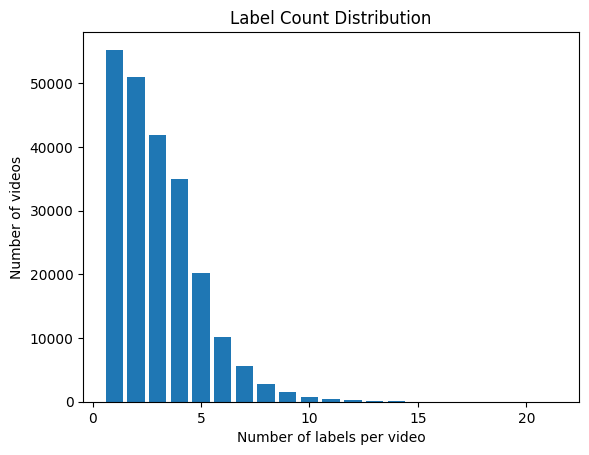

In [23]:
label_count_distribution_plot(df)

### Top-N label distribution

In [24]:
def top_labels(df, top_n=20):
    counter = Counter()

    for x in df["label_names_json"].dropna():
        try:
            labels = json.loads(x)
            counter.update(labels)
        except Exception:
            continue

    total_videos = len(df)

    print(f"\nTOP {top_n} LABELS:")
    for label, cnt in counter.most_common(top_n):
        print(f"{label:40s} {cnt:,} ({cnt/total_videos*100:.2f}%)")

In [25]:
top_labels(df)


TOP 20 LABELS:
Games                                    45,558 (20.24%)
Vehicle                                  31,158 (13.85%)
Video game                               24,291 (10.79%)
Concert                                  21,756 (9.67%)
Car                                      16,558 (7.36%)
Dance                                    13,863 (6.16%)
Animation                                11,788 (5.24%)
Musician                                 11,568 (5.14%)
Football                                 10,548 (4.69%)
Music video                              9,117 (4.05%)
Animal                                   8,456 (3.76%)
Motorsport                               7,904 (3.51%)
Food                                     7,617 (3.38%)
Musical ensemble                         7,137 (3.17%)
Guitar                                   6,657 (2.96%)
Cartoon                                  6,189 (2.75%)
Performance art                          5,793 (2.57%)
Racing                               

In [26]:
def plot_top_labels(df, top_n=20):
    counter = Counter()

    for x in df["label_names_json"].dropna():
        try:
            labels = json.loads(x)
            counter.update(labels)
        except Exception:
            continue

    top = counter.most_common(top_n)
    labels = [x[0] for x in top]
    counts = [x[1] for x in top]

    plt.figure()
    plt.barh(labels, counts)
    plt.xlabel("Number of videos")
    plt.ylabel("Label")
    plt.title(f"Top {top_n} Most Frequent Labels")
    plt.gca().invert_yaxis() 
    plt.show()

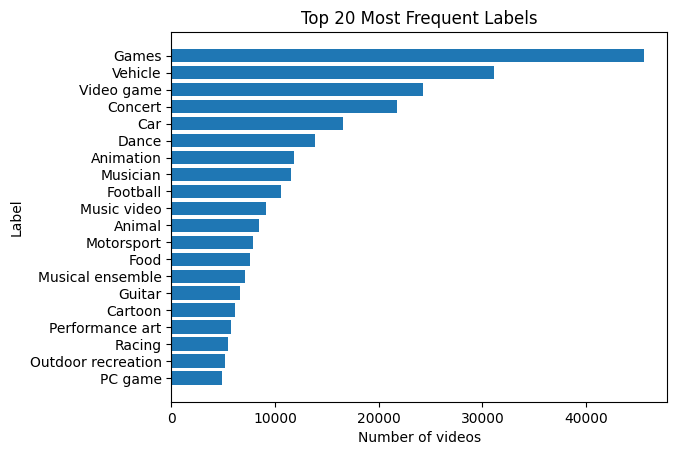

In [27]:
plot_top_labels(df)

## EDA insights
### Dataset Structure
- The dataset provides multi-label annotations for each video.
- The dataset supports multiple modalities; however, this study initially focuses on textual metadata (video titles and tags) as a baseline.
### Text Metadata Coverage Is High but Incomplete
- Textual metadata is available for the majority of the dataset, but 
- Approximately 10% of videos lack any usable text, making a text-only model inherently incomplete.

### Label Distribution Is Highly Imbalanced
The top 20 labels show a strong frequency skew:
- Games appears in 20.24% of all videos.
- Vehicle (13.85%) and Video game (10.79%) further dominate.
- The top 3 labels together cover ≈45% of the dataset.